# Stage 3 Polybot Backtest Visualization

Loads the Kotlin `polybot-backtest` outputs, summarizes contract-level results,
and visualizes the best contract in a stage2-style workflow.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


## Configuration

In [2]:
BACKTEST_DIR = Path('../../data/polybot_backtest')

TRADES_DIR = Path('../../data/polygon_trades_processed')
SELECTED_WALLETS_PATH = Path('../../data/trade_signals_workspace_v2/selected_wallets_v2.parquet')

TOP_N_CONTRACTS = 10
AGGREGATE_RESAMPLE = '1h'
AGGREGATE_MAX_CONTRACTS = None  # Set int for faster iteration during exploration


## Load summaries

In [3]:
summaries_path = BACKTEST_DIR / 'summaries.json'
if not summaries_path.exists():
    raise FileNotFoundError(f'Missing summaries file: {summaries_path}')

summaries = pd.DataFrame(json.loads(summaries_path.read_text()))
if summaries.empty:
    raise ValueError('Backtest summaries are empty.')

summaries['firstTradeAt'] = pd.to_datetime(summaries['firstTradeAt'], utc=True)
summaries['lastTradeAt'] = pd.to_datetime(summaries['lastTradeAt'], utc=True)
summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).head(10)


,conditionId,eventCount,orderCount,fillCount,finalRealizedPnl,finalEstimatedPnl,totalImpliedPnl,finalPosition,finalBuyVolume,finalSellVolume,violationCount,firstTradeAt,lastTradeAt,endDateIso,lastConditionTradeTs,copyWalletPnl
4057,0x16608c4fdd7cb41292f6d42c1c02b43ac22593f1c198...,20253,755,75,4017.172987,4017.142443,4017.184950,0.59,1003.832223,5020.418997,0,2026-06-02 19:21:06+00:00,2026-06-15 00:22:12+00:00,2026-06-15T00:22:12Z,2026-06-15T00:22:12Z,32569.223558
8804,0x3094a2b925483a06aa72945a1472e311e5eb6be75284...,18264,534,43,3850.421566,3850.970457,3851.035365,0.88,886.969686,4737.115487,0,2026-05-25 17:23:23+00:00,2026-06-15 00:21:33+00:00,2026-06-15T00:21:33Z,2026-06-15T00:21:33Z,25578.092042
30648,0xab1209b73e1ce9ebb4905dad781496385b5102c04888...,18831,485,67,2925.670763,2887.947684,2885.362705,57.00,1036.181148,3921.310800,0,2026-06-11 20:34:22+00:00,2026-06-15 02:06:21+00:00,2026-06-15T02:06:21Z,2026-06-15T02:06:21Z,22021.216525
4257,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,14504,698,17,1195.427000,1073.208008,1036.737100,357.85,655.813100,1691.890200,0,2026-06-13 21:02:31+00:00,2026-07-01 22:15:40+00:00,2026-07-01T22:15:40Z,2026-07-01T22:15:40Z,4221.422864
20080,0x6fa13f31cceaf10ed3190df6e2aca0a93ab0d6fb46fd...,50972,1338,45,0.000000,-805.834887,-998.548960,2681.19,998.548960,0.000000,0,2026-04-28 20:07:14+00:00,2026-06-21 13:35:49+00:00,2026-06-21T13:35:49Z,2026-06-21T13:35:49Z,2579.668435
27642,0x9a87a0011494682e4d17a9073059cbbd32ebea4bbc72...,8157,224,21,0.000000,804.895141,1131.705667,1873.58,741.881653,0.000000,0,2026-05-13 04:03:15+00:00,2026-06-01 06:15:23+00:00,2026-06-01T06:15:23Z,2026-06-01T06:15:23Z,5591.880287
24300,0x876047c0df88886ddbe468fe811bc75a667da45a552d...,17067,375,57,0.000000,-793.766703,-867.957335,6947.14,867.957335,0.000000,0,2026-06-02 19:09:50+00:00,2026-06-16 00:32:48+00:00,2026-06-16T00:32:48Z,2026-06-16T00:32:48Z,-19203.552401
8331,0x2de8d7b9d103366e37f3a448db8289c5c571dec5c0b9...,13405,242,38,742.533521,743.013234,743.091715,0.59,365.465558,1107.963450,0,2026-06-12 00:02:46+00:00,2026-06-18 00:30:02+00:00,2026-06-18T00:30:02Z,2026-06-18T00:33:20Z,619.682781
35953,0xc88e812beb27442554b9231273f6cdda7c96022afc1a...,23261,268,44,0.000000,-740.782332,-864.867090,3768.45,864.867090,0.000000,0,2026-06-03 18:23:52+00:00,2026-06-12 00:32:16+00:00,2026-06-12T00:32:16Z,2026-06-12T00:32:16Z,-4797.683410
19188,0x6a8cfe84d17693425f27831db5949d7511f3393d4624...,26850,757,54,0.000000,-661.357392,-999.525856,2257.30,999.525856,0.000000,0,2026-05-23 19:49:26+00:00,2026-06-01 06:09:35+00:00,2026-06-01T06:09:35Z,2026-06-01T06:09:35Z,-35221.787288


In [4]:
totals = {
    'contracts_total': len(summaries),
    'contracts_with_fills': (summaries['fillCount'] > 0).sum(),
    'contracts_with_orders': (summaries['orderCount'] > 0).sum(),
    'total_estimated_pnl': summaries['finalEstimatedPnl'].sum(),
    'mean_estimated_pnl': summaries['finalEstimatedPnl'].mean(),
    'median_estimated_pnl': summaries['finalEstimatedPnl'].median(),
    'min_estimated_pnl': summaries['finalEstimatedPnl'].min(),
    'max_estimated_pnl': summaries['finalEstimatedPnl'].max(),
    'positive_pnl_contracts': (summaries['finalEstimatedPnl'] > 0).sum(),
    'negative_pnl_contracts': (summaries['finalEstimatedPnl'] < 0).sum(),
    'zero_pnl_contracts': (summaries['finalEstimatedPnl'] == 0).sum(),
    'total_orders': int(summaries['orderCount'].sum()),
    'total_fills': int(summaries['fillCount'].sum()),
    'total_events': int(summaries['eventCount'].sum()),
}

pd.DataFrame([totals]).T.rename(columns={0: 'value'})


,value
contracts_total,4.589400e+04
contracts_with_fills,4.759000e+03
contracts_with_orders,7.848000e+03
total_estimated_pnl,1.740147e+04
mean_estimated_pnl,3.791665e-01
median_estimated_pnl,0.000000e+00
min_estimated_pnl,-8.058349e+02
max_estimated_pnl,4.017142e+03
positive_pnl_contracts,1.985000e+03
negative_pnl_contracts,2.339000e+03


## Per-contract stats

In [5]:
display_cols = ['conditionId', 'finalEstimatedPnl', 'finalRealizedPnl', 'orderCount', 'fillCount', 'copyWalletPnl', 'firstTradeAt', 'lastTradeAt']

stats_sorted = summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).reset_index(drop=True)

# top N
stats_sorted.head(TOP_N_CONTRACTS)[display_cols]


,conditionId,finalEstimatedPnl,finalRealizedPnl,orderCount,fillCount,copyWalletPnl,firstTradeAt,lastTradeAt
0,0x16608c4fdd7cb41292f6d42c1c02b43ac22593f1c198...,4017.142443,4017.172987,755,75,32569.223558,2026-06-02 19:21:06+00:00,2026-06-15 00:22:12+00:00
1,0x3094a2b925483a06aa72945a1472e311e5eb6be75284...,3850.970457,3850.421566,534,43,25578.092042,2026-05-25 17:23:23+00:00,2026-06-15 00:21:33+00:00
2,0xab1209b73e1ce9ebb4905dad781496385b5102c04888...,2887.947684,2925.670763,485,67,22021.216525,2026-06-11 20:34:22+00:00,2026-06-15 02:06:21+00:00
3,0x178b29c0bb3a1c482f37f42e2420a1aa686b960ef000...,1073.208008,1195.427000,698,17,4221.422864,2026-06-13 21:02:31+00:00,2026-07-01 22:15:40+00:00
4,0x6fa13f31cceaf10ed3190df6e2aca0a93ab0d6fb46fd...,-805.834887,0.000000,1338,45,2579.668435,2026-04-28 20:07:14+00:00,2026-06-21 13:35:49+00:00
5,0x9a87a0011494682e4d17a9073059cbbd32ebea4bbc72...,804.895141,0.000000,224,21,5591.880287,2026-05-13 04:03:15+00:00,2026-06-01 06:15:23+00:00
6,0x876047c0df88886ddbe468fe811bc75a667da45a552d...,-793.766703,0.000000,375,57,-19203.552401,2026-06-02 19:09:50+00:00,2026-06-16 00:32:48+00:00
7,0x2de8d7b9d103366e37f3a448db8289c5c571dec5c0b9...,743.013234,742.533521,242,38,619.682781,2026-06-12 00:02:46+00:00,2026-06-18 00:30:02+00:00
8,0xc88e812beb27442554b9231273f6cdda7c96022afc1a...,-740.782332,0.000000,268,44,-4797.683410,2026-06-03 18:23:52+00:00,2026-06-12 00:32:16+00:00
9,0x6a8cfe84d17693425f27831db5949d7511f3393d4624...,-661.357392,0.000000,757,54,-35221.787288,2026-05-23 19:49:26+00:00,2026-06-01 06:09:35+00:00


## Per Day Stats

In [6]:
pd.to_datetime(summaries['endDateIso'])

0       2026-06-23 17:16:37+00:00
1       2026-06-01 15:41:06+00:00
2       2026-06-25 12:06:55+00:00
3       2026-07-12 03:05:02+00:00
4       2026-06-09 17:48:48+00:00
                   ...           
45889   2026-07-08 04:04:58+00:00
45890   2026-06-01 08:48:08+00:00
45891   2026-06-14 08:31:10+00:00
45892   2026-07-09 00:14:44+00:00
45893   2026-06-01 12:08:04+00:00
Name: endDateIso, Length: 45894, dtype: datetime64[ns, UTC]

In [7]:
summaries.groupby(pd.to_datetime(summaries['endDateIso']).dt.date).agg(
    contracts=('conditionId', 'count'),
    contracts_with_fills=('fillCount', lambda x: (x > 0).sum()),
    total_estimated_pnl=('finalEstimatedPnl', 'sum'),
    mean_estimated_pnl=('finalEstimatedPnl', 'mean'),
    median_estimated_pnl=('finalEstimatedPnl', 'median')).sort_values('total_estimated_pnl', ascending=False, key=abs).head(10)

,contracts,contracts_with_fills,total_estimated_pnl,mean_estimated_pnl,median_estimated_pnl
endDateIso,,,,,
2026-06-15,1066,136,11383.786506,10.678974,0.0
2026-07-01,1346,136,1237.760952,0.919585,0.0
2026-06-12,1271,106,-1065.785209,-0.838541,0.0
2026-06-09,1026,111,993.054516,0.967889,0.0
2026-07-04,834,88,710.086392,0.851423,0.0
2026-06-23,928,80,-604.251309,-0.651133,0.0
2026-07-14,1049,84,516.036945,0.491932,0.0
2026-06-11,914,103,486.273454,0.532028,0.0
2026-06-02,946,138,484.055749,0.511687,0.0


## Aggregate PnL vs wallet cohort

In [ ]:
selected_wallets_all = pd.read_parquet(SELECTED_WALLETS_PATH, columns=['wallet', 'wallet_group'])
if 'wallet_group' in selected_wallets_all.columns:
    watched_wallets = set(
        selected_wallets_all.loc[selected_wallets_all['wallet_group'] == 'predicting', 'wallet']
        .astype(str)
        .str.lower()
    )
    if not watched_wallets:
        watched_wallets = set(selected_wallets_all['wallet'].astype(str).str.lower())
else:
    watched_wallets = set(selected_wallets_all['wallet'].astype(str).str.lower())

wallet_parts = []
for shard in sorted(TRADES_DIR.glob('*.parquet')):
    df = pd.read_parquet(shard, columns=['wallet', 'dt', 'is_train', 'trade_pnl'])
    df['wallet'] = df['wallet'].astype(str).str.lower()
    mask = (~df['is_train']) & (df['wallet'].isin(watched_wallets))
    wallet_parts.append(df.loc[mask, ['dt', 'trade_pnl']])

if wallet_parts:
    wallet_df = pd.concat(wallet_parts, ignore_index=True)
    wallet_df['dt'] = pd.to_datetime(wallet_df['dt'], utc=True)
else:
    wallet_df = pd.DataFrame(columns=['dt', 'trade_pnl'])

wallet_hourly = (
    wallet_df.set_index('dt')['trade_pnl']
    .resample(AGGREGATE_RESAMPLE)
    .sum()
    .rename('wallet_trade_pnl')
    .to_frame()
) if not wallet_df.empty else pd.DataFrame(columns=['wallet_trade_pnl'])

contract_dirs = sorted((BACKTEST_DIR / 'contracts').glob('*'))
if AGGREGATE_MAX_CONTRACTS is not None:
    contract_dirs = contract_dirs[:AGGREGATE_MAX_CONTRACTS]

valid_conditions = set(summaries['conditionId'])
contract_dirs = [d for d in contract_dirs if d.name in valid_conditions]

pnl_parts = []
for contract_dir in contract_dirs:
    fills_path = contract_dir / 'fills.parquet'
    if not fills_path.exists():
        continue
    fdf = pd.read_parquet(fills_path).dropna(subset=['implied_pnl'])
    if fdf.empty:
        continue
    fdf['dt'] = pd.to_datetime(fdf['dt'], utc=True)
    pnl_parts.append(fdf)

if pnl_parts:
    polybot_all = pd.concat(pnl_parts, ignore_index=True)
    polybot_hourly = (
        polybot_all.set_index('dt')['implied_pnl']
        .resample(AGGREGATE_RESAMPLE)
        .sum()
        .rename('polybot_trade_pnl')
        .to_frame()
    )
else:
    polybot_hourly = pd.DataFrame(columns=['polybot_trade_pnl'])

combined_index = wallet_hourly.index.union(polybot_hourly.index).sort_values()
agg = pd.DataFrame(index=combined_index)
agg = agg.join(wallet_hourly, how='left').join(polybot_hourly, how='left')
agg[['wallet_trade_pnl', 'polybot_trade_pnl']] = agg[['wallet_trade_pnl', 'polybot_trade_pnl']].fillna(0.0)
agg['wallet_cum_trade_pnl'] = agg['wallet_trade_pnl'].cumsum()
agg['polybot_cum_trade_pnl'] = agg['polybot_trade_pnl'].cumsum()

aggregate_totals = pd.DataFrame([
    {'series': 'Wallet cohort cumulative trade_pnl', 'value': float(agg['wallet_cum_trade_pnl'].iloc[-1]) if not agg.empty else 0.0},
    {'series': 'Polybot cumulative traded pnl', 'value': float(agg['polybot_cum_trade_pnl'].iloc[-1]) if not agg.empty else 0.0},
    {'series': 'Polybot final estimated pnl (summaries)', 'value': float(summaries['finalEstimatedPnl'].sum())},
])
aggregate_totals


/private/tmp/ipykernel_20611/1381722907.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fdf['dt'] = pd.to_datetime(fdf['dt'], utc=True)


In [ ]:
polybot_all.groupby('condition_id').agg(
    trade_count=('implied_pnl', 'size'),
    implied_pnl_sum=('implied_pnl', 'sum')
).sort_values('implied_pnl_sum', ascending=False, key=abs).iloc[200:220]

,trade_count,implied_pnl_sum
condition_id,,
0x777f9359419a5dcc103a2b26d06754e9cc8417fe90d62a14f8dbf90fd7c18a3e,13,-31.616227
0x8dcaf5c7acea7f7f0f98410b9250594b955763c5a255acc98d23ff1e4ff9db27,6,31.090000
0xded3d276e139851b39ff6d92343cf08f2bc97f404350f0ae94549cd0720ac57a,7,30.279200
0x2e627b039e20420b37405299bcc5fcf1609380ac8479ba067196069d754dc651,96,-30.218676
0x7981e9099958a08e31c581c9b436b5177be9ab0d54218c08cf80d9a89c518757,2,29.955111
0x1e5c49823af80db76cb12274f20fe0feb1cef7bb5b2f779725b79e31fcd01cfe,3,-29.924800
0x74ce9a266e83c9c8146e430d6f6488e631aa1ea340dff0a265fec7ad8a37b03a,2,-29.760000
0x7ec0cce14fa0831953cc22f6b096c3981061b5df91890ab029bf904c61a3d701,6,29.752684
0x304df128a54337b1daeec77a1489f8fb7cd78610042c6a46575600e85a0323cf,4,-29.750000


In [ ]:
polybot_all#[polybot_all['condition_id'] == '0x9e564dbdf5c9ebdf0860d1970592a269a0ede28570d66a9ea2c50b6f191298d3']

,condition_id,token_id,outcome,dt,source_trade_tx_hash,trigger_wallet,trigger_tx_hash,synthetic_side,synthetic_price,synthetic_quantity,order_id,order_side,order_price,order_quantity,fill_quantity,implied_pnl,order_timestamp,accepted_at,fill_timestamp
0,0x00048586197c3ebb14b5179f32ab00afddd69a215fa640076de22ad1620d792d,91920995257510396874471356033710338910757931075232320306375601859092563222563,No,2026-06-01 02:23:22+00:00,0xc26f69242f04b386fc377fc3e3ab8c1cf1a8ec3df91f7c4d30a72abbc60b31d5,0x3ff7d7f066f51c87791fedaa2b2202dfe62adbfa,0x4b7bf709808a0adf640cc6bd6136f163b659ddc0133a9a28843cee503cd09060,SELL,0.610000,19.810000,order_2e92d195,BUY,0.70,49.0,19.810000,-13.867000,2026-06-01T02:18:28Z,2026-06-01T02:18:28Z,2026-06-01T02:23:22Z
1,0x00048586197c3ebb14b5179f32ab00afddd69a215fa640076de22ad1620d792d,91920995257510396874471356033710338910757931075232320306375601859092563222563,No,2026-06-01 03:30:34+00:00,0xab769096cb88b8f6728641aedf97417d9a71cbf07394923894dbdfe173c04409,None,None,BUY,0.210000,4.640000,order_5e2879da,SELL,0.20,19.0,4.640000,0.928000,2026-06-01T03:27:55Z,2026-06-01T03:29:43Z,2026-06-01T03:30:34Z
2,0x00048586197c3ebb14b5179f32ab00afddd69a215fa640076de22ad1620d792d,91920995257510396874471356033710338910757931075232320306375601859092563222563,No,2026-06-01 03:31:11+00:00,0x23057d34243bc30280b4f939f17ebaea9b189d4bd0807aa6f6dc275871449c90,None,None,BUY,0.210000,20.220000,order_5e286b75,SELL,0.20,15.0,15.000000,3.000000,2026-06-01T03:30:34Z,2026-06-01T03:31:11Z,2026-06-01T03:31:11Z
3,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195,34598697866825296484507866810642771100870032940636565865581929406165006061058,Yes,2026-07-16 06:59:52+00:00,0xe9c71ffab265b32b6d2bbe97dcc9a5a1d30eb1e4cf6715252bc1248cbea87d20,0x85d22a973e817f87afe0a7fd346a39823cce7479,0x7d530c4125b9f64b32a5d8b8cfebf9149288322096a866dc05f95f709db2fa1a,SELL,0.090000,2.674167,order_5128afa0,BUY,0.32,9.0,2.674167,-0.855733,2026-07-16T06:58:37Z,2026-07-16T06:58:37Z,2026-07-16T06:59:52Z
4,0x001588d795d94d974758b12a149d573b3df6fdfb3a61a69fa89e42fb2067538e,99128740718032900042195030247635096805273145226992438375909328758628916349171,No,2026-06-08 23:53:36+00:00,0xc19d0dd0121ae950ac493f4d881058721fa40cecd01e699058e8d47a8e1270bd,0x9e8ecc4cb3c4e48f544cba2fbbb252a6a65e8db8,0x35a0178dc1857dc1f59e773bf1e6822c54403e44d15c4cbbd81ef81ff08564b1,SELL,0.490000,40.000000,order_e108cf68,BUY,0.88,30.0,30.000000,3.600000,2026-06-08T23:53:10Z,2026-06-08T23:53:10Z,2026-06-08T23:53:36Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21058,0xffd03907ce2a60f2f531b84d58fec8727244ed4e4bb7d5ee469d85ac7e112260,55716263188438359762203788790643426616206581621552743248463845270723107280198,No,2026-07-07 01:11:44+00:00,0x95dda8594bd2620d1392c2feb91f080b1af182b2ec8f8ed0e0b1895b9e3dfad5,0xecc8b1562f4a521d0856e3f89c5bfa8bba969335,0xf154376f2bc3ffe318e5e4b0bce930d36fc16824995cfeb9beb1c0f8c1d628ac,SELL,0.950000,23.010000,order_371ef3db,BUY,0.97,6.0,4.010000,0.120300,2026-07-06T23:49:08Z,2026-07-06T23:49:08Z,2026-07-07T01:11:44Z
21059,0xffd59316df4716b9f93fb2f405ac1018b0fdc8202a786f7ad1bae268ebf6e780,31107911138183966715682900402853583885011581605962769228710454376883234975141,Yes,2026-07-14 14:58:22+00:00,0xaf3f4a7b5cf61ac61800a3e82b6e8a13170ef21ab6bc41486d43292769e6e43d,0x5bcd90dc168e93b7f6a7ac21c6bd46a6c338cf4b,0x5b60ddc8b29092d968f23f590535c7b73476fef835a0560e306c17214000fbac,SELL,0.001000,328.690000,order_d422f6cc,BUY,0.01,328.0,328.000000,-3.280000,2026-07-14T14:54:50Z,2026-07-14T14:54:50Z,2026-07-14T14:58:22Z
21060,0xffe3bb89afdab536a6c222a74a764cbe1d977989f2e2dc4eb85b65a38c5497d0,104145229399025063443162244905861233813580266020455249779056252036970532589051,Yes,2026-07-09 06:20:53+00:00,0x7ca7ae8d396b30e03c9b55d37eef6520eba2640fc2e6cb90fcb7b4cceeb9fc08,0x5f612351a9e46afbe3f164473a7d77a69ec9840a,0x17833d03f622341f3910a14d809cf42b58e7971823ce9201a29c796dc0f30902,SELL,0.044000,25.000000,order_46eb5ff6,BUY,0.06,8.0,8.000000,-0.480000,2026-07-09T0

In [ ]:
polybot_all[~polybot_all['trigger_wallet'].isna() & (polybot_all['order_side'] == 'BUY')].groupby('trigger_wallet')['implied_pnl'].sum().sort_values(ascending=False, key=abs).head(20)

trigger_wallet
0x92d0cb81e6c891b835c8e0272e8c323095bd269e    3700.972748
0xdaa6a2cd4ba545befb3dbdc25d2b444c46873e62    2082.770189
0x41583f2efc720b8e2682750fffb67f2806fece9f    1812.192864
0x8b72cb885a6bd4ea9d1da393ca231f0fa3476dbe    1601.166976
0x165ed327dd594bfe95a5a9836cad385813cff5aa   -1518.671582
0x134a63b764ac7b008356e8db1857db94e6b09e42    1476.079827
0x0cb10c40b0776e9ee8cef970af85724654dda76c    1345.824379
0xcf6a714618a328c608a1c70cb62a31a6bef3f9d0    1285.339510
0x68c24bf4a8ad4d79a6fe4b8eec6f93a02dfd1711    1268.653365
0x736539924a5602b37a03a54fc12c1cc8f98964da    1145.840017
0x22dbd51e1a4e10fff072fa24300238c64033190f   -1110.748181
0x755cbd7d95ba3d3f9ccafb9f27b35251fd25e9ae   -1038.930431
0x6df6e2a9ba1e8d7609daada0a83138817f4a8458     838.200513
0x1d1aa3439835cc8dbb5e55d615bee3f39b0d324e    -752.033314
0x6d16c33b540069f5aa0d9f705b0d759dec927228    -733.766361
0xe732156a2d84cdfb4de831d3f11a22899e49898f     625.946613
0x672225e5e1aba1c970ac613efd1505f4b7a10762    -496.217647

In [ ]:
polybot_all.groupby('trigger_wallet').agg(
    trade_count=('implied_pnl', 'size'),
    implied_pnl_sum=('implied_pnl', 'sum')
).sort_values('implied_pnl_sum', ascending=False, key=abs)

,trade_count,implied_pnl_sum
trigger_wallet,,
0x92d0cb81e6c891b835c8e0272e8c323095bd269e,310,3700.972748
0xdaa6a2cd4ba545befb3dbdc25d2b444c46873e62,127,2082.770189
0x41583f2efc720b8e2682750fffb67f2806fece9f,226,1812.192864
0x8b72cb885a6bd4ea9d1da393ca231f0fa3476dbe,86,1601.166976
0x165ed327dd594bfe95a5a9836cad385813cff5aa,58,-1518.671582
...,...,...
0x36bbe5da9b309f7e17e7c2ac0d9df57e2c336bd8,11,9.323500
0xb9012e0d9b60d3920286309328b935cdfa609fc4,83,4.965366
0x8cf02c9d05a70aad0b02468ac0824c08a8b773b4,2,-3.460000


In [ ]:
fig_global = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
    subplot_titles=('Cumulative PnL (all watched wallets/contracts)', 'Per-bucket traded PnL')
)

fig_global.add_trace(
    go.Scatter(x=agg.index, y=agg['wallet_cum_trade_pnl'], mode='lines', name='Wallet cohort cumulative trade_pnl'),
    row=1, col=1
)
fig_global.add_trace(
    go.Scatter(x=agg.index, y=agg['polybot_cum_trade_pnl'], mode='lines', name='Polybot cumulative traded pnl'),
    row=1, col=1
)

fig_global.add_trace(
    go.Bar(x=agg.index, y=agg['wallet_trade_pnl'], name='Wallet cohort trade_pnl (bucket)'),
    row=2, col=1
)
fig_global.add_trace(
    go.Bar(x=agg.index, y=agg['polybot_trade_pnl'], name='Polybot traded pnl (bucket)'),
    row=2, col=1
)

fig_global.update_layout(
    height=850, template='plotly_white',
    title='Global aggregation: all watched wallets/contracts vs polybot traded pnl',
    barmode='group',
)
fig_global.show()


In [ ]:
df.head()

,wallet,dt,is_train,trade_pnl
0,0x0004d52aaa42a3da333ced548b45b420c31880c7,2026-03-25 09:46:07+00:00,True,105.405405
1,0x0004d52aaa42a3da333ced548b45b420c31880c7,2026-03-25 17:03:15+00:00,True,-10.999999
2,0x00085583a8bed6e0fef83387c0f9a3753f00efa9,2026-03-24 02:59:31+00:00,True,-12.000000
3,0x00090e8b4fa8f88dc9c1740e460dd0f670021d43,2025-09-22 01:39:34+00:00,True,76.563060
4,0x00090e8b4fa8f88dc9c1740e460dd0f670021d43,2025-09-22 03:05:50+00:00,True,0.961910


## Order-fill delay analysis

In [ ]:
# Load fill data for ALL contracts — computes delays and wallet stats in one pass
all_delays = []
wallet_parts = []

contract_dirs = sorted((BACKTEST_DIR / 'contracts').glob('*'))
if AGGREGATE_MAX_CONTRACTS is not None:
    contract_dirs = contract_dirs[:AGGREGATE_MAX_CONTRACTS]

for contract_dir in contract_dirs:
    fills_path = contract_dir / 'fills.parquet'
    if not fills_path.exists():
        continue
    df = pd.read_parquet(fills_path, columns=[
        'condition_id', 'token_id', 'dt',
        'trigger_wallet', 'synthetic_side',
        'synthetic_price', 'fill_quantity',
        'order_side', 'order_price',
        'implied_pnl',
        'order_timestamp', 'fill_timestamp'
    ])
    if df.empty:
        continue
    df['dt'] = pd.to_datetime(df['dt'], utc=True)
    df['order_timestamp'] = pd.to_datetime(df['order_timestamp'], utc=True)
    df['fill_timestamp'] = pd.to_datetime(df['fill_timestamp'], utc=True)
    df['delay_s'] = (df['fill_timestamp'] - df['order_timestamp']).dt.total_seconds()
    df['notional'] = df['fill_quantity'] * df['synthetic_price']
    all_delays.append(df[['condition_id', 'delay_s']])
    wallet_parts.append(df)

all_delays_df = pd.concat(all_delays, ignore_index=True) if all_delays else pd.DataFrame(columns=['condition_id', 'delay_s'])
all_delays_df = all_delays_df[all_delays_df['delay_s'] >= 0]

wallet_all = pd.concat(wallet_parts, ignore_index=True) if wallet_parts else pd.DataFrame(
    columns=['condition_id', 'token_id', 'dt', 'trigger_wallet', 'synthetic_side', 'synthetic_price', 'fill_quantity', 'order_side', 'order_price', 'notional', 'implied_pnl', 'delay_s']
)

# Add last condition trade timestamp per condition
_last_ts = wallet_all.groupby('condition_id')['fill_timestamp'].max().rename('last_condition_trade_ts')
wallet_all = wallet_all.merge(_last_ts, on='condition_id', how='left')

print(f'Fill events loaded: {len(all_delays_df):,}')
print(f'Contracts with fills: {all_delays_df["condition_id"].nunique():,}')
print(f'Unique trigger wallets: {wallet_all["trigger_wallet"].nunique()}')


/private/tmp/ipykernel_87970/2439720632.py:23: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/private/tmp/ipykernel_87970/2439720632.py:24: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/private/tmp/ipykernel_87970/2439720632.py:25: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/private/tmp/ipykernel_87970/2439720632.py:24: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Fill events loaded: 21,063
Contracts with fills: 4,759
Unique trigger wallets: 72


In [ ]:
# -- ALL contracts --
delay_stats = all_delays_df['delay_s'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
print('Order-fill delay stats — ALL contracts with fills')
print(delay_stats.to_string())
print()

# -- TOP-N by abs PnL --
top_ids = set(summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).head(TOP_N_CONTRACTS)['conditionId'])
top_delays = all_delays_df[all_delays_df['condition_id'].isin(top_ids)]

if not top_delays.empty:
    print(f'Order-fill delay stats — TOP-{TOP_N_CONTRACTS} contracts by abs PnL')
    print(f'Fill events: {len(top_delays):,} | Contracts: {top_delays["condition_id"].nunique()}')
    print(top_delays['delay_s'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_string())
else:
    print(f'No fill events found in the top-{TOP_N_CONTRACTS} contracts.')


Order-fill delay stats — ALL contracts with fills
count    2.106300e+04
mean     2.376745e+03
std      2.867732e+04
min      1.000000e+00
25%      1.900000e+01
50%      1.600000e+02
75%      8.610000e+02
90%      2.642400e+03
95%      4.572500e+03
99%      3.376136e+04
max      2.586983e+06

Order-fill delay stats — TOP-10 contracts by abs PnL
Fill events: 990 | Contracts: 10
count      990.000000
mean       291.965657
std        741.893622
min          1.000000
25%          5.000000
50%         30.000000
75%        207.250000
90%        827.500000
95%       1479.850000
99%       3608.670000
max      10516.000000


In [ ]:
import numpy as np

log_delays = np.log10(all_delays_df['delay_s'].clip(lower=1))

fig_delay = go.Figure()
fig_delay.add_trace(go.Histogram(
    x=log_delays,
    nbinsx=80,
    name='All contracts'
))

median_val = all_delays_df['delay_s'].median()
median_log = np.log10(max(median_val, 1))
fig_delay.add_vline(x=median_log, line_dash='dash', line_color='red',
                    annotation_text=f'median={median_val:.0f}s', annotation_position='top right')

max_log = int(np.ceil(log_delays.max()))
tickvals = list(range(0, max_log + 1))
ticktext = ['1s', '10s', '1m', '10m', '1.7h', '11.6h', '4.8d'][:max_log + 1]

fig_delay.update_layout(
    title='Order-fill delay distribution (all contracts) — log10 scale',
    xaxis_title='Delay',
    yaxis_title='Fill events',
    template='plotly_white', height=500,
)
fig_delay.update_xaxes(tickvals=tickvals, ticktext=ticktext)
fig_delay.show()


## Wallet-level stats

In [ ]:
from collections import deque

# Aggregate wallet stats
wallet_stats = wallet_all.groupby('trigger_wallet').agg(
    fill_count=('condition_id', 'count'),
    unique_contracts=('condition_id', 'nunique'),
    total_notional=('notional', 'sum'),
    avg_notional=('notional', 'mean'),
    total_implied_pnl=('implied_pnl', 'sum'),
    median_delay_s=('delay_s', 'median'),
    avg_delay_s=('delay_s', 'mean'),
).sort_values('fill_count', ascending=False)

# FIFO PnL attribution per (condition_id, token_id)
# BUY fills go into a queue; SELL fills match against the queue
# PnL = (sell_price - buy_price) * matched_qty, attributed to SELL's trigger_wallet
pnl_per_wallet = {}

for (cond_id, token_id), grp in wallet_all.groupby(['condition_id', 'token_id'], sort=False):
    grp = grp.sort_values('dt')
    buy_queue = deque()

    for _, row in grp.iterrows():
        side = row['synthetic_side']
        qty = row['fill_quantity']
        price = row['synthetic_price']
        wallet = row['trigger_wallet'] if pd.notna(row['trigger_wallet']) else None

        if side == 'BUY':
            buy_queue.append([qty, price, wallet])
        else:
            remaining = qty
            while remaining > 1e-10 and buy_queue:
                buy_qty, buy_price, _ = buy_queue[0]
                matched = min(remaining, buy_qty)
                pnl = (price - buy_price) * matched
                if wallet is not None:
                    pnl_per_wallet[wallet] = pnl_per_wallet.get(wallet, 0.0) + pnl
                if matched >= buy_qty - 1e-10:
                    buy_queue.popleft()
                else:
                    buy_queue[0][0] -= matched
                remaining -= matched

wallet_stats['attributed_pnl'] = wallet_stats.index.to_series().map(pnl_per_wallet).fillna(0.0).round(2)
wallet_stats['total_implied_pnl'] = wallet_stats['total_implied_pnl'].round(2)

# Comparison
diff = (wallet_stats['attributed_pnl'] - wallet_stats['total_implied_pnl']).abs()
print(f'Attributed PnL total: {wallet_stats["attributed_pnl"].sum():.2f}')
print(f'Implied PnL total:    {wallet_stats["total_implied_pnl"].sum():.2f}')
print(f'Mean abs diff:        {diff.mean():.4f}')
print(f'Correlation:          {wallet_stats["attributed_pnl"].corr(wallet_stats["total_implied_pnl"]):.4f}')

wallet_stats['total_notional'] = wallet_stats['total_notional'].round(2)
wallet_stats['avg_notional'] = wallet_stats['avg_notional'].round(2)
wallet_stats['median_delay_s'] = wallet_stats['median_delay_s'].round(1)
wallet_stats['avg_delay_s'] = wallet_stats['avg_delay_s'].round(1)

print('Top 15 wallets by attributed PnL:')
wallet_stats = wallet_stats.sort_values('attributed_pnl', ascending=False, key=abs)
wallet_stats.head(15)


Attributed PnL total: -186.31
Implied PnL total:    12713.66
Mean abs diff:        421.3785
Correlation:          0.1341
Top 15 wallets by attributed PnL:


,fill_count,unique_contracts,total_notional,avg_notional,total_implied_pnl,median_delay_s,avg_delay_s,attributed_pnl
trigger_wallet,,,,,,,,
0x92d0cb81e6c891b835c8e0272e8c323095bd269e,310,75,7691.86,24.81,3700.97,39.0,414.7,584.00
0x0cb10c40b0776e9ee8cef970af85724654dda76c,124,43,1887.73,15.22,1345.82,102.0,2660.4,-551.71
0xa0bca9bdd8540da95060ed1fafb78aa03835d428,220,57,3413.68,15.52,278.32,35.5,1041.8,-531.65
0xdaa6a2cd4ba545befb3dbdc25d2b444c46873e62,127,32,1904.34,14.99,2082.77,41.0,708.2,421.65
0xac761dd9b3a373cc9031dabaab1ecec546299359,336,80,3099.46,9.22,-90.62,102.0,938.3,326.94
0x165ed327dd594bfe95a5a9836cad385813cff5aa,58,34,2507.83,43.24,-1518.67,640.5,8260.7,305.83
0x1d1aa3439835cc8dbb5e55d615bee3f39b0d324e,81,51,1928.19,23.80,-752.03,120.0,5096.3,213.10
0xcf6a714618a328c608a1c70cb62a31a6bef3f9d0,215,16,2388.29,11.11,1285.34,78.0,549.2,203.69
0x41583f2efc720b8e2682750fffb67f2806fece9f,226,62,4250.10,18.81,1812.19,86.0,628.3,-199.97


In [ ]:
# wallet_all[~wallet_all['trigger_wallet'].isna()]['implied_pnl'].sum()

In [ ]:
top15 = wallet_stats.head(15)

fig_wallet = go.Figure()
fig_wallet.add_trace(go.Bar(
    x=top15.index.str[:10] + '...',
    y=top15['fill_count'],
    marker_color='royalblue',
    text=top15['fill_count'],
    textposition='outside',
))

fig_wallet.update_layout(
    title='Top wallets by fill count',
    xaxis_title='Wallet',
    yaxis_title='Fill count',
    template='plotly_white',
    height=500,
    margin=dict(b=120),
)
fig_wallet.update_xaxes(tickangle=45)
fig_wallet.show()


In [ ]:
top15_pnl = wallet_stats.head(20)

fig_pnl = go.Figure()
colors = ['green' if v >= 0 else 'red' for v in top15_pnl['attributed_pnl']]
fig_pnl.add_trace(go.Bar(
    x=top15_pnl.index.str[:10] + '...',
    y=top15_pnl['attributed_pnl'],
    marker_color=colors,
    text=top15_pnl['attributed_pnl'].round(1),
    textposition='outside',
))

fig_pnl.update_layout(
    title='Top wallets by attributed PnL (FIFO)',
    xaxis_title='Wallet',
    yaxis_title='Attributed PnL',
    template='plotly_white',
    height=500,
    margin=dict(b=120),
)
fig_pnl.update_xaxes(tickangle=45)
fig_pnl.show()


## Top contracts PnL comparison

In [ ]:
top_contracts = summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).head(TOP_N_CONTRACTS).reset_index(drop=True)

pnl_parts = []
for _, row in top_contracts.iterrows():
    cid = row['conditionId']
    fills_path = BACKTEST_DIR / 'contracts' / cid / 'fills.parquet'
    if not fills_path.exists():
        continue
    fdf = pd.read_parquet(fills_path, columns=['dt', 'implied_pnl']).dropna(subset=['implied_pnl'])
    if fdf.empty:
        continue
    fdf['dt'] = pd.to_datetime(fdf['dt'], utc=True)
    fdf = fdf.sort_values('dt')
    contract_pnl = fdf.groupby('dt', as_index=False)['implied_pnl'].sum()
    contract_pnl['cum_pnl'] = contract_pnl['implied_pnl'].cumsum()
    contract_pnl['condition_id'] = cid
    pnl_parts.append(contract_pnl[['dt', 'cum_pnl', 'condition_id']])

if pnl_parts:
    pnl_all = pd.concat(pnl_parts, ignore_index=True)

    fig_top = go.Figure()
    for cid, grp in pnl_all.groupby('condition_id'):
        short_id = cid[:10] + '...' + cid[-6:]
        fig_top.add_trace(go.Scatter(
            x=grp['dt'], y=grp['cum_pnl'],
            mode='lines', name=short_id
        ))

    fig_top.update_layout(
        title=f'Cumulative PnL for top-{TOP_N_CONTRACTS} contracts by absolute PnL',
        xaxis_title='Date', yaxis_title='Cumulative PnL',
        template='plotly_white', height=600,
        legend=dict(font=dict(size=8)),
    )
    fig_top.show()
else:
    print('No fills.parquet data found for top contracts.')


## Detailed timeline: best contract

In [ ]:
best_cid = summaries.sort_values('finalEstimatedPnl', ascending=False, key=abs).iloc[0]['conditionId']
best_dir = BACKTEST_DIR / 'contracts' / best_cid

parts = []
for row_type, file_name in [('stats', 'stats.parquet'), ('order', 'orders.parquet'), ('fill', 'fills.parquet'), ('public_trade', 'public_trades.parquet'), ('plan_fact', 'plan_facts.parquet')]:
    path = best_dir / file_name
    if path.exists():
        df = pd.read_parquet(path)
        df['row_type'] = row_type
        parts.append(df)

if not parts:
    raise FileNotFoundError(f'No parquet files found in {best_dir}')

events = pd.concat(parts, ignore_index=True)
events['dt'] = pd.to_datetime(events['dt'], utc=True)

print(f'Best contract: {best_cid}')
summary = json.loads((best_dir / 'summary.json').read_text())
print(f'Estimated PnL: {summary["finalEstimatedPnl"]:.2f}')
events.head()


Best contract: 0x3094a2b925483a06aa72945a1472e311e5eb6be75284f61e0c008e279508ddf6
Estimated PnL: 1353.54


,condition_id,token_id,outcome,dt,position_after,total_buy_volume,total_sell_volume,realized_pnl,est_pnl,best_bid,...,fill_quantity,implied_pnl,order_timestamp,accepted_at,fill_timestamp,wallet,public_side,public_price,public_quantity,facts
0,0x3094a2b925483a06aa72945a1472e311e5eb6be75284f61e0c008e279508ddf6,2573721445147198402794802928157427663327297748733430491619487131647218857169,Yes,2026-05-28 21:05:06+00:00,29.99,13.798335,0.00,0.00,0.315040,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0x3094a2b925483a06aa72945a1472e311e5eb6be75284f61e0c008e279508ddf6,70659432139994542069434772104144657639869399273651484864261399963742293385083,No,2026-05-28 21:05:06+00:00,0.00,0.000000,0.00,0.00,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0x3094a2b925483a06aa72945a1472e311e5eb6be75284f61e0c008e279508ddf6,2573721445147198402794802928157427663327297748733430491619487131647218857169,Yes,2026-05-28 22:48:55+00:00,0.99,13.798335,11.31,-2.03,-2.109690,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0x3094a2b925483a06aa72945a1472e311e5eb6be75284f61e0c008e279508ddf6,2573721445147198402794802928157427663327297748733430491619487131647218857169,Yes,2026-06-03 09:28:18+00:00,500.99,143.798335,11.31,-2.03,-4.533201,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0x3094a2b925483a06aa72945a1472e311e5eb6be75284f61e0c008e279508ddf6,70659432139994542069434772104144657639869399273651484864261399963742293385083,No,2026-06-03 09:28:18+00:00,0.00,0.000000,0.00,0.00,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
timeline = events[events['row_type'] == 'stats'][['dt', 'token_id', 'outcome', 'position_after', 'realized_pnl', 'est_pnl', 'best_bid', 'best_ask', 'fair_price', 'vwap5m', 'vwap15m', 'vwap1h']].copy()
timeline = timeline.sort_values(['dt', 'token_id']).reset_index(drop=True)

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                     subplot_titles=('Estimated / Realized PnL', 'Position', 'Prices'))

for token_id, grp in timeline.groupby('token_id', sort=False):
    label = grp['outcome'].iloc[0]
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['est_pnl'], name=f'{label} est pnl', mode='lines'), row=1, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['realized_pnl'], name=f'{label} realized pnl', mode='lines', line=dict(dash='dot')), row=1, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['position_after'], name=f'{label} position', mode='lines'), row=2, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['fair_price'], name=f'{label} fair', mode='lines'), row=3, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['best_bid'], name=f'{label} bid', mode='lines', line=dict(dash='dot')), row=3, col=1)
    fig.add_trace(go.Scatter(x=grp['dt'], y=grp['best_ask'], name=f'{label} ask', mode='lines', line=dict(dash='dot')), row=3, col=1)

fig.update_layout(height=1000, template='plotly_white', title=f'Detailed timeline: {best_cid[:10]}...{best_cid[-6:]}')
fig.show()


In [ ]:
from polymarket_analysis.data.data_catalogue import load_markets_processed
mdf = load_markets_processed()
mdf = mdf[
    ~(mdf['primary_tag'].isin(['Sports', 'Crypto']))
    & (mdf['winner_token_id'].notna())
    ].copy().reset_index(drop=True)

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
wallet_all[wallet_all['condition_id'] == '0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195']

,condition_id,token_id,dt,trigger_wallet,synthetic_side,synthetic_price,fill_quantity,order_side,order_price,implied_pnl,order_timestamp,fill_timestamp,delay_s,notional,last_condition_trade_ts
3,0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195,34598697866825296484507866810642771100870032940636565865581929406165006061058,2026-07-16 06:59:52+00:00,0x85d22a973e817f87afe0a7fd346a39823cce7479,SELL,0.09,2.674167,BUY,0.32,-0.855733,2026-07-16 06:58:37+00:00,2026-07-16 06:59:52+00:00,75.0,0.240675,2026-07-16 06:59:52+00:00


In [ ]:
# Net exposition over time using FIFO cost basis, with resolution resets at lastTradeAt

# Optional: filter to specific contracts for investigation
# Set to None to compute over all contracts (default).
# Examples:
CONTRACT_FILTER = None  # {'0x000f8958f3be79021a7fa7c4513f450b46da408aba3e0779596bc20cbb64a195'}
#   CONTRACT_FILTER = set(summaries.sort_values('finalEstimatedPnl', ascending=False).head(5)['conditionId'])

# Load summaries for resolution proxy
with open(BACKTEST_DIR / "summaries.json") as f:
    _summaries = pd.DataFrame(json.load(f))
_summaries['lastTradeAt'] = pd.to_datetime(_summaries['lastTradeAt'], format='mixed', utc=True)
_resolved_at = dict(zip(_summaries['conditionId'], _summaries['lastTradeAt']))

# Per-contract FIFO exposure at each fill timestamp
expo_parts = []
for cid, grp in wallet_all.sort_values('dt').groupby('condition_id'):
    if CONTRACT_FILTER is not None and cid not in CONTRACT_FILTER:
        continue
    grp = grp.sort_values('dt')
    long_q = []
    short_q = []
    realized_pnl = 0.0
    buy_vol_acc = 0.0
    sell_vol_acc = 0.0
    rows = []
    for _, row in grp.iterrows():
        qty = row['fill_quantity']
        price = row['order_price']
        if row['order_side'] == 'BUY':
            buy_vol_acc += qty * price
            remaining = qty
            while remaining > 0 and short_q:
                avail, p = short_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (price - p)
                remaining -= match
                if match == avail:
                    short_q.pop(0)
                else:
                    short_q[0] = (avail - match, p)
            if remaining > 0:
                long_q.append((remaining, price))
        else:
            sell_vol_acc += qty * price
            remaining = qty
            while remaining > 0 and long_q:
                avail, p = long_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (p - price)
                remaining -= match
                if match == avail:
                    long_q.pop(0)
                else:
                    long_q[0] = (avail - match, p)
            if remaining > 0:
                short_q.append((remaining, price))

        exposure = sum(q * p for q, p in long_q) + sum(q * p for q, p in short_q)
        if exposure < 0:
            exposure = 0.0
        if cid in _resolved_at and row['dt'] >= _resolved_at[cid]:
            exposure = 0.0
        rows.append({'condition_id': cid, 'dt': row['dt'], 'exposition': exposure})

    expo_parts.append(pd.DataFrame(rows))

    # Reset to 0 at resolution time so the aggregate drops immediately
    if cid in _resolved_at:
        expo_parts.append(pd.DataFrame([{'condition_id': cid, 'dt': _resolved_at[cid], 'exposition': 0.0}]))

expo_all = pd.concat(expo_parts, ignore_index=True) if expo_parts else pd.DataFrame(
    columns=['condition_id', 'dt', 'exposition']
)

# Per-contract validation breakdown
if not expo_all.empty:
    _last_per_cid = expo_all.groupby('condition_id')['exposition'].last().reset_index()
    _last_per_cid.columns = ['condition_id', 'exposition']
    _active = _last_per_cid[_last_per_cid['exposition'] > 0].sort_values('exposition', ascending=False)
    print(f"=== Per-contract exposition breakdown{" (filtered)" if CONTRACT_FILTER is not None else ""} ===")
    print(_active.to_string(index=False))
    print(f"\nContracts with exposition > 0: {len(_active)}")
    print(f"Sum of per-contract exposition: {_active['exposition'].sum():.2f}")

# Aggregate across all contracts at each timestamp
# Forward-fill each contract's exposition then sum across contracts
# Each contract's exposition persists until its next fill or resolution
_expo_sorted = expo_all.sort_values(['condition_id', 'dt'])
_expo_sorted['_delta'] = _expo_sorted.groupby('condition_id')['exposition'].diff()
_first_idx = _expo_sorted.groupby('condition_id').head(1).index
_expo_sorted.loc[_first_idx, '_delta'] = _expo_sorted.loc[_first_idx, 'exposition']
ts = _expo_sorted.groupby('dt', as_index=False)['_delta'].sum().sort_values('dt')
ts['exposition'] = ts['_delta'].cumsum()
ts = ts.drop(columns=['_delta'])

if not ts.empty:
    print(f"Aggregate exposition (from ts sum): {ts['exposition'].iloc[-1]:.2f}")

# Cumulative PnL on secondary axis for comparison
_pnl_df = wallet_all if CONTRACT_FILTER is None else wallet_all[wallet_all['condition_id'].isin(CONTRACT_FILTER)]
pnl_ts = _pnl_df.groupby('dt', as_index=False)['implied_pnl'].sum().sort_values('dt')
pnl_ts['cum_pnl'] = pnl_ts['implied_pnl'].cumsum()

# Compute exact snapshot exposure at TARGET_TS for marker overlay
TARGET_TS = "2026-07-17T09:32:52Z"
cutoff = pd.Timestamp(TARGET_TS, tz='UTC')
snap_df = wallet_all[wallet_all['dt'] <= cutoff].copy()
expo_parts_snap = []
for cid, grp in snap_df.sort_values('dt').groupby('condition_id'):
    if CONTRACT_FILTER is not None and cid not in CONTRACT_FILTER:
        continue
    if cid in _resolved_at and _resolved_at[cid] <= cutoff:
        continue
    long_q = []
    short_q = []
    realized_pnl = 0.0
    buy_vol = 0.0
    sell_vol = 0.0
    for _, row in grp.iterrows():
        qty = row['fill_quantity']
        price = row['order_price']
        if row['order_side'] == 'BUY':
            buy_vol += qty * price
            remaining = qty
            while remaining > 0 and short_q:
                avail, p = short_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (price - p)
                remaining -= match
                if match == avail:
                    short_q.pop(0)
                else:
                    short_q[0] = (avail - match, p)
            if remaining > 0:
                long_q.append((remaining, price))
        else:
            sell_vol += qty * price
            remaining = qty
            while remaining > 0 and long_q:
                avail, p = long_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (p - price)
                remaining -= match
                if match == avail:
                    long_q.pop(0)
                else:
                    long_q[0] = (avail - match, p)
            if remaining > 0:
                short_q.append((remaining, price))
    exposure = sum(q * p for q, p in long_q) + sum(q * p for q, p in short_q)
    if exposure < 0:
        exposure = 0.0
    expo_parts_snap.append(exposure)
snap = sum(expo_parts_snap)
ts = pd.concat([ts, pd.DataFrame([{'dt': cutoff, 'exposition': snap}])], ignore_index=True).sort_values('dt').drop_duplicates('dt')

# Clip to the fills period
fill_start = wallet_all['dt'].min()
fill_end = wallet_all['dt'].max()
ts = ts[(ts['dt'] >= fill_start) & (ts['dt'] <= fill_end)]
pnl_ts = pnl_ts[(pnl_ts['dt'] >= fill_start) & (pnl_ts['dt'] <= fill_end)]

fig_ntl = make_subplots(specs=[[{'secondary_y': True}]])

fig_ntl.add_trace(go.Scatter(
    x=ts['dt'], y=ts['exposition'],
    mode='lines', name='Net exposition (FIFO cost basis, USD)',
    line=dict(color='royalblue', width=2),
), secondary_y=False)

fig_ntl.add_trace(go.Scatter(
    x=pnl_ts['dt'], y=pnl_ts['cum_pnl'],
    mode='lines', name='Cumulative implied PnL',
    line=dict(color='darkorange', width=2, dash='dot'),
), secondary_y=True)

fig_ntl.add_trace(go.Scatter(
    x=[cutoff], y=[snap],
    mode='markers', name=f'Expo at {TARGET_TS} = {snap:.2f}',
    marker=dict(color='red', size=10, symbol='x'),
), secondary_y=False)

fig_ntl.update_layout(
    title='Net exposition vs cumulative PnL over time',
    template='plotly_white', height=500,
    legend=dict(x=0.5, y=-0.2, orientation='h'),
)
fig_ntl.update_xaxes(title='Date')
fig_ntl.update_yaxes(title='Net exposition (FIFO cost basis, USD)', secondary_y=False)
fig_ntl.update_yaxes(title='Cumulative implied PnL', secondary_y=True)
fig_ntl.show()


=== Per-contract exposition breakdown ===
Empty DataFrame
Columns: [condition_id, exposition]
Index: []

Contracts with exposition > 0: 0
Sum of per-contract exposition: 0.00
Aggregate exposition (from ts sum): 0.00


In [ ]:
# Exposure per condition at a snapshot using FIFO cost basis
# exposure = FIFO cost basis of remaining open positions
# = sum of (qty * price) for all remaining long and short positions
cutoff = pd.Timestamp(TARGET_TS, tz='UTC')

# Load summaries for resolution proxy (lastTradeAt = contract end)
with open(BACKTEST_DIR / "summaries.json") as f:
    summaries = pd.DataFrame(json.load(f))
summaries['lastTradeAt'] = pd.to_datetime(summaries['lastTradeAt'], format='mixed', utc=True)
resolved_at = dict(zip(summaries['conditionId'], summaries['lastTradeAt']))

contracts_dir = BACKTEST_DIR / "contracts"
valid_conditions = set(summaries['conditionId'])
results = []

for cid_dir in sorted(contracts_dir.iterdir()):
    cid = cid_dir.name
    if not cid_dir.is_dir():
        continue
    if cid not in valid_conditions:
        continue
    # Skip resolved contracts (lastTradeAt before cutoff = no remaining exposure)
    if cid in resolved_at and resolved_at[cid] <= cutoff:
        continue
    fills_path = cid_dir / "fills.parquet"
    if not fills_path.exists():
        continue
    fills = pd.read_parquet(fills_path)
    fills['fill_ts'] = pd.to_datetime(fills['fill_timestamp'], format='mixed', utc=True)
    fills = fills[fills['fill_ts'] <= cutoff].copy()
    if fills.empty:
        continue
    fills = fills.sort_values('fill_ts')

    buy_vol = (fills[fills['order_side'] == 'BUY']['fill_quantity'] * fills[fills['order_side'] == 'BUY']['order_price']).sum()
    sell_vol = (fills[fills['order_side'] == 'SELL']['fill_quantity'] * fills[fills['order_side'] == 'SELL']['order_price']).sum()

    # FIFO realized PnL (entry - exit convention: profit = buy_price - sell_price)
    long_q = []
    short_q = []
    realized_pnl = 0.0

    for _, row in fills.iterrows():
        qty = row['fill_quantity']
        price = row['order_price']
        if row['order_side'] == 'BUY':
            remaining = qty
            while remaining > 0 and short_q:
                avail, p = short_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (price - p)
                remaining -= match
                if match == avail:
                    short_q.pop(0)
                else:
                    short_q[0] = (avail - match, p)
            if remaining > 0:
                long_q.append((remaining, price))
        else:
            remaining = qty
            while remaining > 0 and long_q:
                avail, p = long_q[0]
                match = min(remaining, avail)
                realized_pnl += match * (p - price)
                remaining -= match
                if match == avail:
                    long_q.pop(0)
                else:
                    long_q[0] = (avail - match, p)
            if remaining > 0:
                short_q.append((remaining, price))

    exposure = sum(q * p for q, p in long_q) + sum(q * p for q, p in short_q)
    if exposure < 0:
        exposure = 0.0

    buy_qty = fills[fills['order_side'] == 'BUY']['fill_quantity'].sum()
    sell_qty = fills[fills['order_side'] == 'SELL']['fill_quantity'].sum()
    position = buy_qty - sell_qty

    results.append({
        'condition_id': cid,
        'position': position,
        'buyVolume': buy_vol,
        'sellVolume': sell_vol,
        'realizedPnl': realized_pnl,
        'exposure': exposure,
    })

results_df = pd.DataFrame(results)
if results_df.empty:
    print(f"No active (unresolved) conditions with fills found at cutoff {TARGET_TS}")
else:
    results_df['abs_exposure'] = results_df['exposure'].abs()
    results_df = results_df.sort_values('exposure', ascending=False)

    print(f"=== Exposure per condition at {TARGET_TS} ===")
    print(f"Formula: exposure = buyVolume - sellVolume + fifoRealizedPnl")
    print(f"         = FIFO cost basis of remaining position (realized PnL added back)")
    print(f"Resolved contracts (lastTradeAt <= cutoff) excluded from exposure")
    print()
    print(f"{'condition_id':<68} {'pos':>8} {'exposure':>10} {'buyVol':>10} {'sellVol':>10} {'realPnL':>10}")
    print("=" * 121)
    for _, r in results_df.head(20).iterrows():
        print(f"{r['condition_id']:<68} {r['position']:>8.1f} {r['exposure']:>10.2f} {r['buyVolume']:>10.2f} {r['sellVolume']:>10.2f} {r['realizedPnl']:>10.2f}")
    print()
    print(f"Active (unresolved) conditions with fills: {len(results_df)}")
    print(f"Conditions with exposure > 0: {(results_df['exposure'] > 0).sum()}")
    print(f"Sum of all exposure: {results_df['exposure'].sum():.2f}")


=== Exposure per condition at 2026-07-17T09:32:52Z ===
Formula: exposure = buyVolume - sellVolume + fifoRealizedPnl
         = FIFO cost basis of remaining position (realized PnL added back)
Resolved contracts (lastTradeAt <= cutoff) excluded from exposure

condition_id                                                              pos   exposure     buyVol    sellVol    realPnL
0xa8c5938408a247e61d4cc9ae3f49f7a6562a381ec14c5f96bc6255644420c730       87.7      74.06      75.28       1.04       0.17
0x8cce4fac8f603ccdb730b31b631ff98c2ba0ee376303f857ebee39aad88a04c3       73.7      71.45      71.45       0.00       0.00
0xd1bb7552943d2403bb56fc3eaf03a1c28d8b48db16aa48eebc76e9c429cf05d8       88.1      23.62      23.62       0.00       0.00
0xbffc696b6a9d602c6c28f1c63d307d7ae3a0f2ccb32a720177209f2e2f3c28a0       19.0      17.14      17.14       0.00       0.00
0xeb8bf42eb2dfbbb35d40d2a30e2db6302da24cd8bfe8c9fd57df690898706c85       29.0      13.92      13.92       0.00       0.00
0xea49ab06

In [ ]:
d = polybot_all
d['buy_pnl'] = d['implied_pnl'].where(d['order_side'] == 'BUY', 0.0)

In [ ]:
d[d['condition_id'] == '0xa03297730d7a5c27db5e05fd5e2a74beae291918e5f3eb8cf665f995df00fd3e'].sort_values('dt')

,condition_id,token_id,outcome,dt,source_trade_tx_hash,trigger_wallet,trigger_tx_hash,synthetic_side,synthetic_price,synthetic_quantity,order_id,order_side,order_price,order_quantity,fill_quantity,implied_pnl,order_timestamp,accepted_at,fill_timestamp,buy_pnl
13597,0xa03297730d7a5c27db5e05fd5e2a74beae291918e5f3eb8cf665f995df00fd3e,76102987470194602832988720304434669924277403086265957261377523873417091497426,Down,2026-07-01 12:26:08+00:00,0xeb09da9e9e362e7f32a7f8d6edb1210e2f5c79d997121f240d5f4d00d266dcc4,0x956718c60d076b911d81ade20bb457dbb331e505,0x24f8ab1720b2045be88debaa9b3cebc9b97aa07bc0ab8567cb89d6b786697447,SELL,0.59,141.410000,order_5fbf8c74,BUY,0.63,200.0,141.41,52.3217,2026-07-01T12:17:35Z,2026-07-01T12:17:35Z,2026-07-01T12:26:08Z,52.3217
13598,0xa03297730d7a5c27db5e05fd5e2a74beae291918e5f3eb8cf665f995df00fd3e,76102987470194602832988720304434669924277403086265957261377523873417091497426,Down,2026-07-01 12:26:08+00:00,0xeb09da9e9e362e7f32a7f8d6edb1210e2f5c79d997121f240d5f4d00d266dcc4,0x956718c60d076b911d81ade20bb457dbb331e505,0x24f8ab1720b2045be88debaa9b3cebc9b97aa07bc0ab8567cb89d6b786697447,SELL,0.60,100.000000,order_5fbf8c74,BUY,0.63,200.0,58.59,21.6783,2026-07-01T12:17:35Z,2026-07-01T12:17:35Z,2026-07-01T12:26:08Z,21.6783
13599,0xa03297730d7a5c27db5e05fd5e2a74beae291918e5f3eb8cf665f995df00fd3e,76102987470194602832988720304434669924277403086265957261377523873417091497426,Down,2026-07-01 15:20:53+00:00,0xc5e1f3034d215af6916851b8cdec0865d9d0956c7c08c239392756d9a9247ab7,None,None,BUY,0.24,0.990000,order_8f5a4bbb,SELL,0.23,200.0,0.99,-0.7623,2026-07-01T15:20:52Z,2026-07-01T15:20:52Z,2026-07-01T15:20:53Z,0.0000
13600,0xa03297730d7a5c27db5e05fd5e2a74beae291918e5f3eb8cf665f995df00fd3e,76102987470194602832988720304434669924277403086265957261377523873417091497426,Down,2026-07-01 15:34:47+00:00,0x977862f1e3190d5bf565f09f5bcf7899afcfa15e6eff74efcbb52ed7e9962bab,None,None,BUY,0.22,898.350908,order_8f5960f9,SELL,0.21,199.0,199.00,-157.2100,2026-07-01T15:28:17Z,2026-07-01T15:28:17Z,2026-07-01T15:34:47Z,0.0000


In [ ]:
dd = d.groupby('condition_id').agg(
    trade_count=('implied_pnl', 'size'),
    implied_pnl_sum=('implied_pnl', 'sum'),
    buy_pnl_sum=('buy_pnl', 'sum')
)

dd = dd[(dd['buy_pnl_sum'] > 0) & (dd['implied_pnl_sum'] < 0)].sort_values('implied_pnl_sum', ascending=False, key=abs)

dd[dd['trade_count'] < 10].sort_values('implied_pnl_sum', ascending=False, key=abs)

,trade_count,implied_pnl_sum,buy_pnl_sum
condition_id,,,
0xa03297730d7a5c27db5e05fd5e2a74beae291918e5f3eb8cf665f995df00fd3e,4,-83.972300,74.000000
0x053d22e12bfe8dd73b12fc1cf89858ecc0de76aede10fea3eca5c7877d8db40c,6,-65.877700,38.082300
0x0ce87bea5e3c0af78f4c6c8121443268a23041c2da5900cb176b316c222c081d,4,-65.700000,33.000000
0x253439470dbcdeb4d399564da6cf9dce449f3f72da0514164fc9982d8d712d07,3,-35.500000,0.500000
0xa6e388d87a81a17dd8f2046479e11c50bf32bcf475ce75a3506c5cf19a09613c,7,-31.814838,37.839162
...,...,...,...
0x63da95665236ce59229b9a9fb829fa50173b1443c97570535b078815ab3c92e1,2,-0.040000,0.820000
0x73b467c13d55dc5551e5a423c063bb88b84f23c76af6d035d668148c90719f65,2,-0.037500,1.852500
0x8ded982488297731ef304289f93276c6b84b13522e27698e0a04e2da1b6b4c18,3,-0.032175,4.117825


In [ ]:
d.groupby('trigger_wallet')['implied_pnl'].sum().sort_values(ascending=False, key=abs).head(20)

trigger_wallet
0x92d0cb81e6c891b835c8e0272e8c323095bd269e    3700.972748
0xdaa6a2cd4ba545befb3dbdc25d2b444c46873e62    2082.770189
0x41583f2efc720b8e2682750fffb67f2806fece9f    1812.192864
0x8b72cb885a6bd4ea9d1da393ca231f0fa3476dbe    1601.166976
0x165ed327dd594bfe95a5a9836cad385813cff5aa   -1518.671582
0x134a63b764ac7b008356e8db1857db94e6b09e42    1476.079827
0x0cb10c40b0776e9ee8cef970af85724654dda76c    1345.824379
0xcf6a714618a328c608a1c70cb62a31a6bef3f9d0    1285.339510
0x68c24bf4a8ad4d79a6fe4b8eec6f93a02dfd1711    1268.653365
0x736539924a5602b37a03a54fc12c1cc8f98964da    1145.840017
0x22dbd51e1a4e10fff072fa24300238c64033190f   -1110.748181
0x755cbd7d95ba3d3f9ccafb9f27b35251fd25e9ae   -1038.930431
0x6df6e2a9ba1e8d7609daada0a83138817f4a8458     838.200513
0x1d1aa3439835cc8dbb5e55d615bee3f39b0d324e    -752.033314
0x6d16c33b540069f5aa0d9f705b0d759dec927228    -733.766361
0xe732156a2d84cdfb4de831d3f11a22899e49898f     625.946613
0x672225e5e1aba1c970ac613efd1505f4b7a10762    -496.217647

,order_price,n_fills,win_rate,mean_ret,std_ret,total_pnl,sharpe
0,0.01,1086,0.007366,-0.002634,0.085551,-333.635426,-0.588109
1,0.02,557,0.017953,-0.002047,0.132901,-186.255910,-0.294217
2,0.03,472,0.042373,0.012373,0.201652,126.351942,1.172235
3,0.04,407,0.044226,0.004226,0.205850,-29.564406,0.392220
4,0.05,422,0.021327,-0.028673,0.144644,-452.667780,-3.787218
...,...,...,...,...,...,...,...
94,0.95,115,0.878261,-0.071739,0.328415,-73.199728,-4.173296
95,0.96,95,0.947368,-0.012632,0.224481,-42.633376,-1.075037
96,0.97,119,0.983193,0.013193,0.129090,-245.382896,1.952566
97,0.98,134,0.977612,-0.002388,0.148497,-470.233630,-0.307237


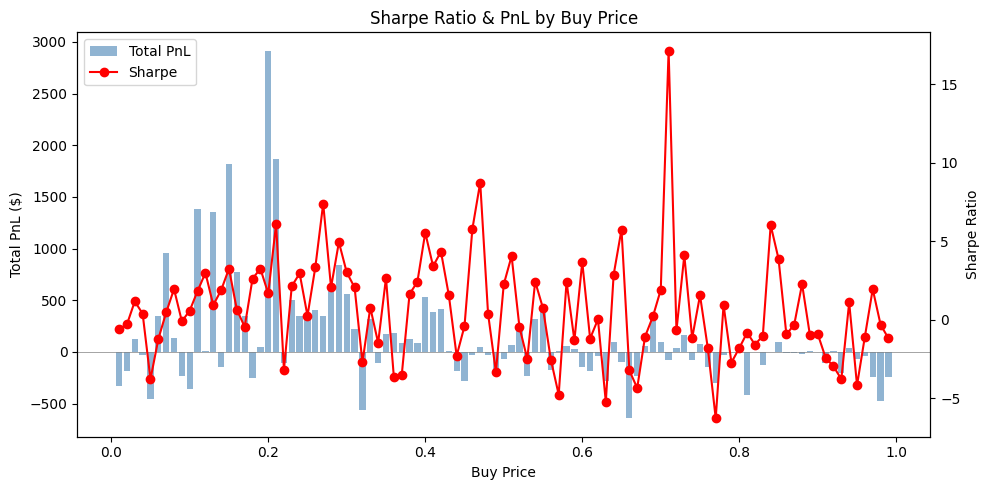

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Per-fill return: PnL per unit filled

buy_df = wallet_all[wallet_all['order_side'] == 'BUY'].copy()
buy_df['ret'] = buy_df['implied_pnl'] / buy_df['fill_quantity']

# Sharpe per buy price
results = []
for price, grp in buy_df.groupby('order_price'):
    d = grp['ret']
    total_pnl = grp['implied_pnl'].sum()
    n = len(grp)
    win_rate = (d > 0).sum() / n
    mean_ret = d.mean()
    std_ret = d.std()
    sharpe = mean_ret / std_ret * np.sqrt(365) if std_ret > 0 else np.nan
    results.append({
        'order_price': price, 'n_fills': n, 'win_rate': win_rate,
        'mean_ret': mean_ret, 'std_ret': std_ret, 'total_pnl': total_pnl, 'sharpe': sharpe,
    })
result = pd.DataFrame(results).sort_values('order_price')
display(result)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(result['order_price'], result['total_pnl'], width=0.008, alpha=0.6, color='steelblue', label='Total PnL')
ax1.set_xlabel('Buy Price')
ax1.set_ylabel('Total PnL ($)')
ax1.axhline(0, color='grey', linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(result['order_price'], result['sharpe'], 'ro-', markersize=6, label='Sharpe')
ax2.set_ylabel('Sharpe Ratio')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Sharpe Ratio & PnL by Buy Price')
plt.tight_layout()
plt.show()